# Model Interpretability

## Importing

In [1]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import xgboost
import lightgbm
import shap
import lime
from utils import *

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading artifacts

In [2]:
data = joblib.load("../data/processed/processed_data.joblib")
X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

In [3]:
best_model = joblib.load("../models/Ridge Stacking Ensemble_model.joblib")

## Ensemble Model Feature Importance

,Features,Scores
0,ElasticNet,1.000000
1,XGBoost Regressor,0.001766
2,LightGBM Regressor,0.000000


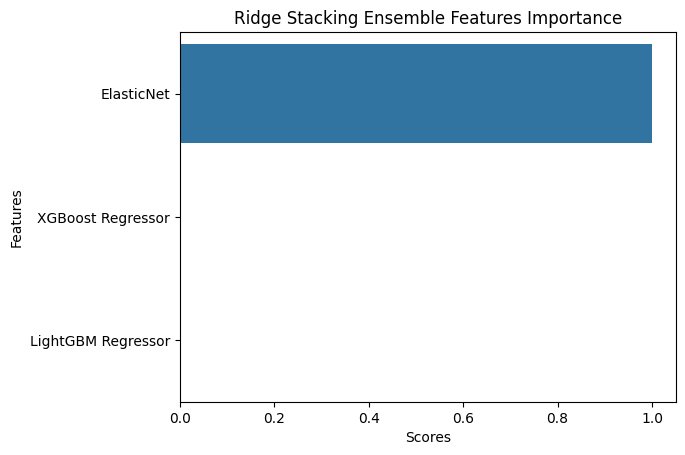

In [4]:
showing_normalized_features_importance(model_name=MODEL_04_NAME, features_importances=best_model.feature_importances_, X=pd.DataFrame(columns=[f"{MODEL_01_NAME}", f"{MODEL_02_NAME}", f"{MODEL_03_NAME}"]))

## Getting the base fitted models

In [5]:
best_base_model = best_model.get_trained_base_models()[0]
type(best_base_model)

sklearn.linear_model._coordinate_descent.ElasticNet

In [6]:
second_base_model = best_model.get_trained_base_models()[1]
type(second_base_model)

xgboost.sklearn.XGBRegressor

In [7]:
third_base_model = best_model.get_trained_base_models()[2]
type(third_base_model)

lightgbm.sklearn.LGBMRegressor

## Global Methods

### Feature Importance

#### ElasticNet

,Features,Scores
1,High,1.000000
2,Low,0.698512
0,Open,0.209467
6,Company,0.003157
9,Date_quarter,0.000625
5,Stock_Splits,0.000245
7,Date_day_of_week,0.000245
4,Dividends,0.000245
11,Date_day_of_year,0.000173
12,Date_month_sin,0.000150


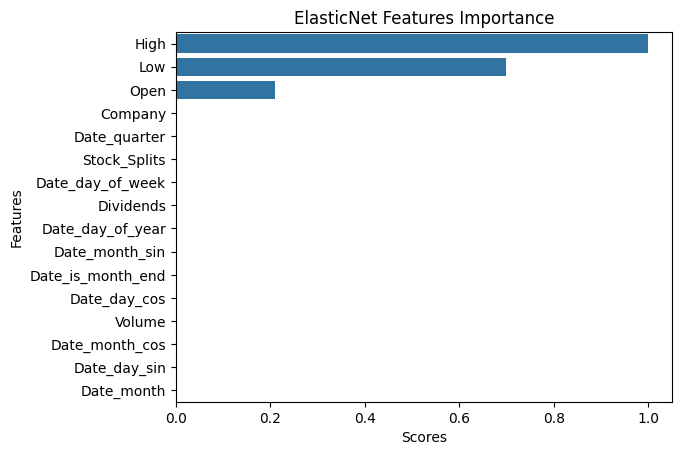

In [8]:
showing_normalized_features_importance(model_name=MODEL_01_NAME, features_importances=best_base_model.coef_, X=X_train)

#### XGBoost Regressor

,Features,Scores
2,Low,1.000000
0,Open,0.941273
1,High,0.878305
3,Volume,0.480091
6,Company,0.061562
11,Date_day_of_year,0.007112
8,Date_month,0.005839
13,Date_month_cos,0.004517
12,Date_month_sin,0.001976
7,Date_day_of_week,0.000000


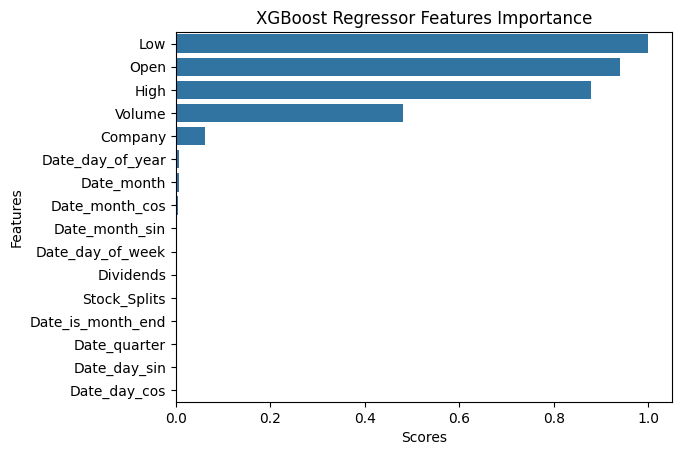

In [9]:
showing_normalized_features_importance(model_name=MODEL_02_NAME, features_importances=second_base_model.feature_importances_, X=X_train)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

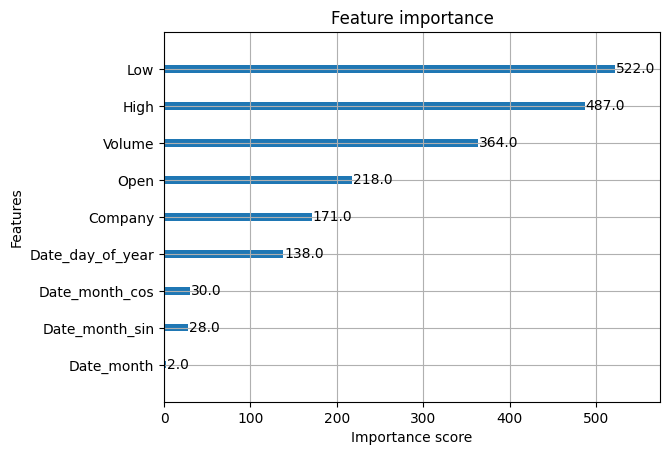

In [10]:
xgboost.plot_importance(second_base_model)

#### LightGBM Regressor

,Features,Scores
1,High,1.000000
2,Low,0.974348
6,Company,0.344457
0,Open,0.240905
11,Date_day_of_year,0.008140
3,Volume,0.005011
13,Date_month_cos,0.000607
8,Date_month,0.000420
12,Date_month_sin,0.000374
7,Date_day_of_week,0.000202


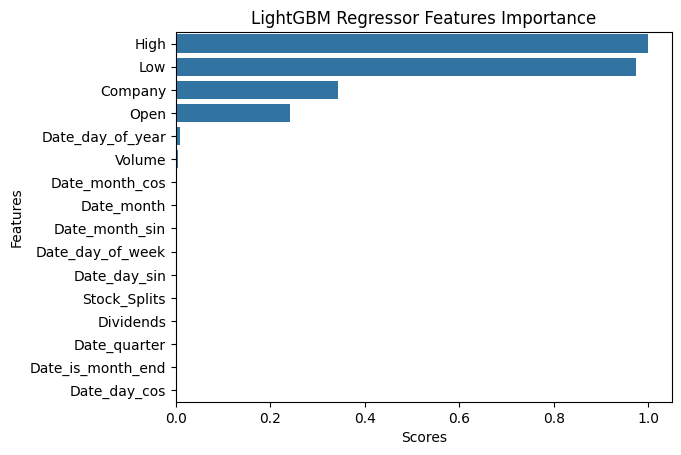

In [11]:
showing_normalized_features_importance(model_name=MODEL_03_NAME, features_importances=third_base_model.booster_.feature_importance(importance_type="gain"), X=X_train)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

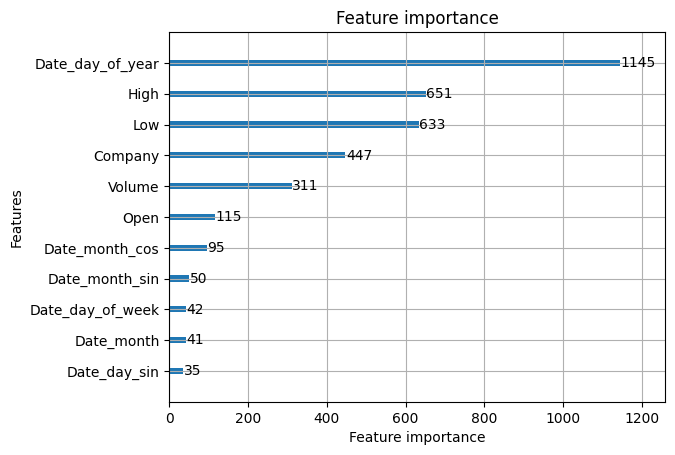

In [12]:
lightgbm.plot_importance(third_base_model, importance_type="split")

### Permutation Importance

#### ElasticNet

,Features,Scores
1,High,5.455772e-01
2,Low,2.699622e-01
0,Open,2.420894e-02
6,Company,4.963512e-06
8,Date_month,5.277444e-08
14,Date_day_sin,4.764783e-08
3,Volume,1.973361e-08
11,Date_day_of_year,1.166635e-08
7,Date_day_of_week,0.000000e+00
5,Stock_Splits,0.000000e+00


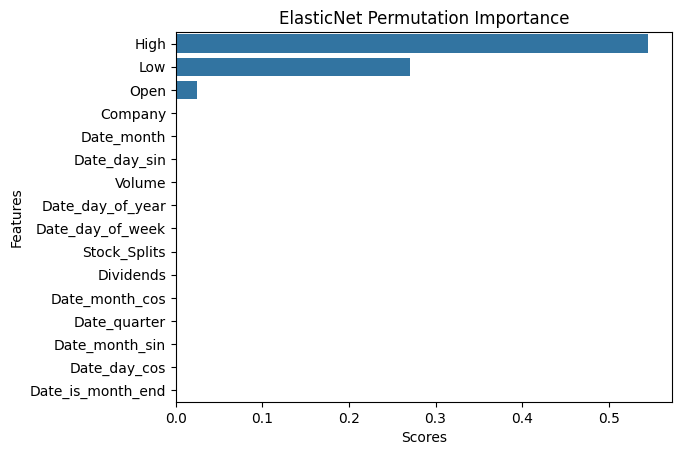

In [14]:
showing_permutation_importance(model_name=MODEL_01_NAME, model=best_base_model, X=X_test, y=y_test)

#### XGBoost Regressor

,Features,Scores
2,Low,0.302988
1,High,0.244327
0,Open,0.199696
3,Volume,0.162265
6,Company,0.021624
12,Date_month_sin,0.000112
11,Date_day_of_year,0.000101
4,Dividends,0.000000
7,Date_day_of_week,0.000000
5,Stock_Splits,0.000000


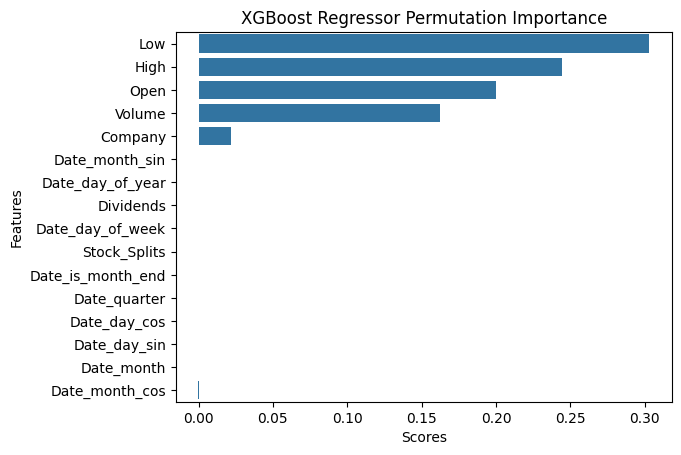

In [15]:
showing_permutation_importance(model_name=MODEL_02_NAME, model=second_base_model, X=X_test, y=y_test)

#### LightGBM Regressor

,Features,Scores
1,High,0.328132
2,Low,0.298870
6,Company,0.186721
0,Open,0.056254
3,Volume,0.028927
11,Date_day_of_year,0.000992
7,Date_day_of_week,0.000120
13,Date_month_cos,0.000047
14,Date_day_sin,0.000021
5,Stock_Splits,0.000000


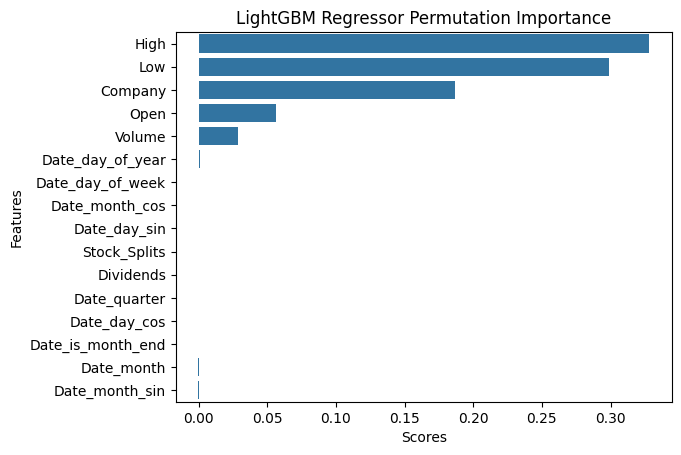

In [16]:
showing_permutation_importance(model_name=MODEL_03_NAME, model=third_base_model, X=X_test, y=y_test)

### Partial Dependence Plot (PDP)

#### ElasticNet

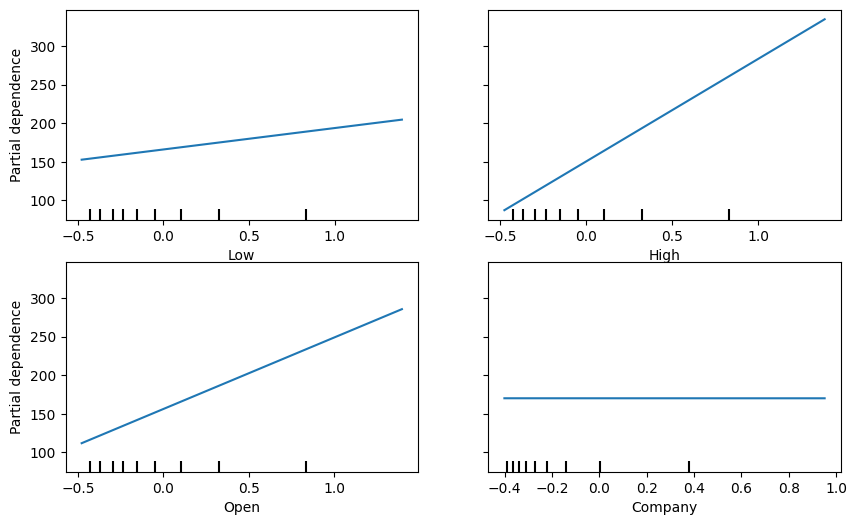

In [50]:
PartialDependenceDisplay.from_estimator(best_base_model, X_test, features=range(4), feature_names=["Low","High","Open","Company"], kind="average", n_cols=2).figure_.set_size_inches(10, 6)

#### XGBoost Regressor

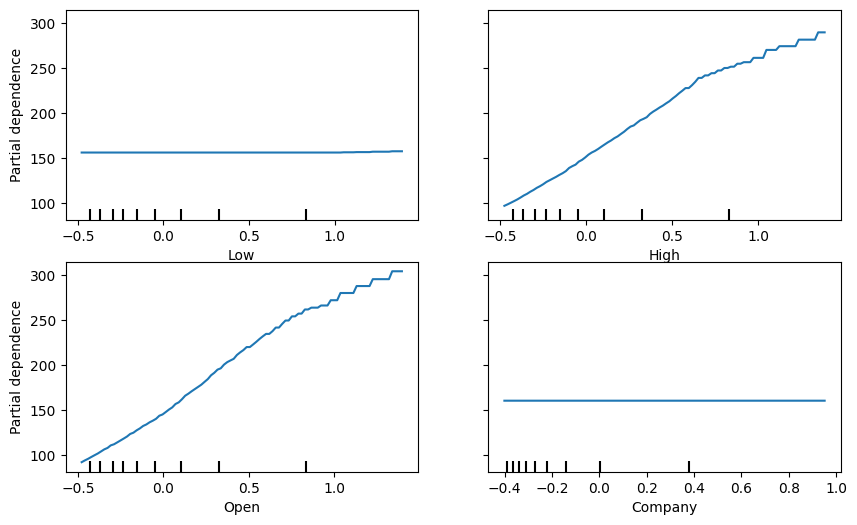

In [51]:
PartialDependenceDisplay.from_estimator(second_base_model, X_test, features=range(4), feature_names=["Low","High","Open","Company"], kind="average", n_cols=2).figure_.set_size_inches(10, 6)

#### LightGBM Regressor

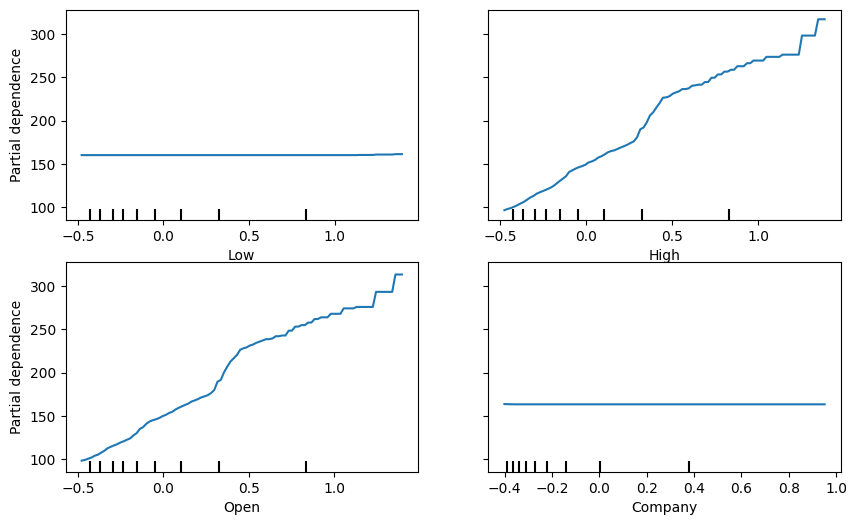

In [52]:
PartialDependenceDisplay.from_estimator(third_base_model, X_test, features=range(4), feature_names=["Low","High","Open","Company"], kind="average", n_cols=2).figure_.set_size_inches(10, 6)